In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

In [13]:
diabetes = datasets.load_diabetes(as_frame=True)
df = diabetes.frame
df.head(20)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


# Problem Framing

The lab seeks to establish a forecasting model which predicts diabetes development during the second year from baseline initiation. Multiple models will be developed for assessment using the metrics of R-squared and Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE) among others to determine their predictive power. The forecast prediction will establish the intensity of care needed for individuals based on its results.

In [14]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


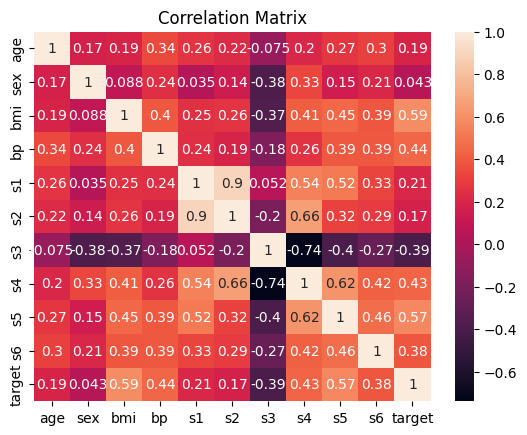

In [15]:
correlation = df.corr()
plt.Figure()
sns.heatmap(correlation, annot= True)
plt.title("Correlation Matrix")
plt.show()

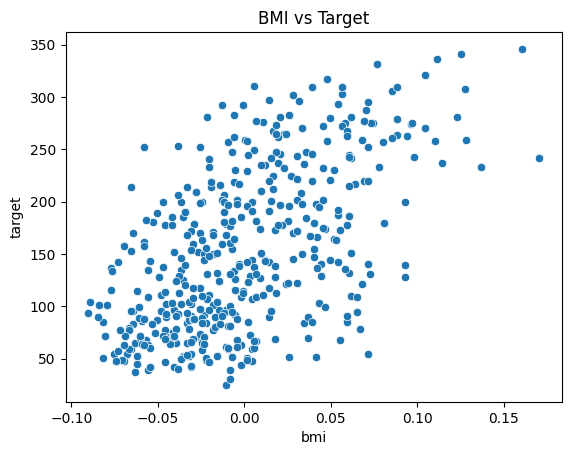

In [16]:
sns.scatterplot(x=df['bmi'], y=df['target'])
plt.title('BMI vs Target')
plt.show()

In [17]:
X = diabetes.data[["bmi"]].values
y = diabetes.target.values.reshape(-1, 1)

train_size = int(len(X) * 0.75)
val_size = int(len(X) * 0.10)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [18]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    return r2, mae, mape

In [19]:
results = []
models = []

In [20]:
for degree in range(6):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    r2_train, mae_train, mape_train = evaluate_model(model, X_train_poly, y_train)
    r2_val, mae_val, mape_val = evaluate_model(model, X_val_poly, y_val)
    
    models.append((degree, model, poly))
    results.append([degree, r2_train, mae_train, mape_train, r2_val, mae_val, mape_val])

In [50]:
results_df = pd.DataFrame(results, columns=["Degree", "R2 Train", "MAE Train", "MAPE Train", "R2 Val", "MAE Val", "MAPE Val"])
(results_df)

,Degree,R2 Train,MAE Train,MAPE Train,R2 Val,MAE Val,MAPE Val
0,0,0.000000,64.736339,61.307286,-0.035692,68.838025,52.586199
1,1,0.324504,52.100347,48.119410,0.442344,48.799466,35.198844
2,2,0.327573,51.809102,47.841737,0.408676,49.808875,35.501182
3,3,0.327586,51.796375,47.817121,0.412079,49.676010,35.409087
4,4,0.330671,51.671484,47.588790,0.339617,51.777645,35.941586
5,5,0.331279,51.660339,47.595364,0.376086,51.051367,35.720699


In [22]:
best_degree = results_df.sort_values(by="R2 Val", ascending=False).iloc[0]["Degree"]
best_model, best_poly = models[int(best_degree)][1], models[int(best_degree)][2]

In [23]:
X_test_poly = best_poly.transform(X_test)
r2_test, mae_test, mape_test = evaluate_model(best_model, X_test_poly, y_test)
print(f"Best model degree: {best_degree}")
print(f"Test R2: {r2_test}")
print(f"Test MAE: {mae_test}")
print(f"Test MAPE: {mape_test}")

Best model degree: 1.0
Test R2: 0.3544143076342602
Test MAE: 52.34503929494629
Test MAPE: 52.50441747965887


In [49]:
intercept = best_model.intercept_[0]
coefficients = best_model.coef_.flatten()[1:]
equation = f"y = {intercept:.2f}"
for i, coef in enumerate(coefficients):
    equation += f" + {coef:.2f}x^{i+1}"
print("Equation of the best model:")
equation

Equation of the best model:


'y = 151.49 + 941.47x^1'

In [26]:
BMI_value = np.array([[25]])  # Example BMI value
BMI_poly = best_poly.transform(BMI_value)
predicted_progression = best_model.predict(BMI_poly)
print(f"Predicted diabetes progression for BMI {BMI_value[0][0]}: {predicted_progression[0][0]:.2f}")

Predicted diabetes progression for BMI 25: 23688.12


In [27]:
for degree, model, poly in models:
    print(f"Degree: {degree}")
    print(f"Number of trainable parameters: {len(poly.get_feature_names_out())}")
    print("---")

Degree: 0
Number of trainable parameters: 1
---
Degree: 1
Number of trainable parameters: 2
---
Degree: 2
Number of trainable parameters: 3
---
Degree: 3
Number of trainable parameters: 4
---
Degree: 4
Number of trainable parameters: 5
---
Degree: 5
Number of trainable parameters: 6
---


# Conclusion:

The validation performance reached its optimal point when the polynomial regression model had a degree of 1.0.
The model performs less accurately when the degree of the model becomes higher than needed because of overfitting.
The main restrictions of polynomial regression exist during extrapolation and when subjected to noisy data.
Additional improvement potentials would result from implementing regularization algorithms as well as integrating decision trees and neural networks.

# Part 3


In [ ]:
degrees = [2, 3]
results_poly = []

for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)
    y_test_pred = model.predict(X_test_poly)
    
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    
    r2_val = r2_score(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mape_val = mean_absolute_percentage_error(y_val, y_val_pred)
    
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    
    results_poly.append({
        'Degree': degree,
        'Train R2': r2_train, 'Train MAE': mae_train, 'Train MAPE': mape_train,
        'Val R2': r2_val, 'Val MAE': mae_val, 'Val MAPE': mape_val,
        'Test R2': r2_test, 'Test MAE': mae_test, 'Test MAPE': mape_test
    })

results_poly_df = pd.DataFrame(results_poly)
print("Polynomial Regression Results:")
results_poly_df

,Degree,Train R2,Train MAE,Train MAPE,Val R2,Val MAE,Val MAPE,Test R2,Test MAE,Test MAPE
0,2,0.327573,51.809102,0.478417,0.408676,49.808875,0.355012,0.348235,52.437034,0.528693
1,3,0.327586,51.796375,0.478171,0.412079,49.676010,0.354091,0.347896,52.418945,0.528620


In [ ]:
max_depths = [3, 5]
results_tree = []

for max_depth in max_depths:
    model = DecisionTreeRegressor(max_depth=max_depth)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    
    r2_val = r2_score(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mape_val = mean_absolute_percentage_error(y_val, y_val_pred)
    
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    
    results_tree.append({
        'Max Depth': max_depth,
        'Train R2': r2_train, 'Train MAE': mae_train, 'Train MAPE': mape_train,
        'Val R2': r2_val, 'Val MAE': mae_val, 'Val MAPE': mape_val,
        'Test R2': r2_test, 'Test MAE': mae_test, 'Test MAPE': mape_test
    })

results_tree_df = pd.DataFrame(results_tree)
print("Decision Tree Results:")
results_tree_df

Decision Tree Results:


,Max Depth,Train R2,Train MAE,Train MAPE,Val R2,Val MAE,Val MAPE,Test R2,Test MAE,Test MAPE
0,3,0.377953,49.609633,0.454479,0.369156,52.155590,0.360537,0.380642,49.084988,0.503203
1,5,0.457430,45.588693,0.419313,0.153663,60.274467,0.441667,0.310291,50.313731,0.501934


In [53]:
k_values = [3, 5]
results_knn = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    
    r2_val = r2_score(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mape_val = mean_absolute_percentage_error(y_val, y_val_pred)
    
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    
    results_knn.append({
        'k': k,
        'Train R2': r2_train, 'Train MAE': mae_train, 'Train MAPE': mape_train,
        'Val R2': r2_val, 'Val MAE': mae_val, 'Val MAPE': mape_val,
        'Test R2': r2_test, 'Test MAE': mae_test, 'Test MAPE': mape_test
    })

results_knn_df = pd.DataFrame(results_knn)
print("kNN Results:")
results_knn_df

kNN Results:


,k,Train R2,Train MAE,Train MAPE,Val R2,Val MAE,Val MAPE,Test R2,Test MAE,Test MAPE
0,3,0.519753,42.795569,0.377182,0.258909,55.000000,0.433497,0.192726,53.258706,0.559977
1,5,0.473439,45.701511,0.394376,0.305140,53.372727,0.383707,0.299377,52.119403,0.528462
